# Código atualizado


In [1]:
# ============================================
# 1) Bloco: Imports
# ============================================
import warnings
import os
import shutil
import pandas as pd
import numpy as np
import math

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier 
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


In [2]:
# ============================================
# 2) Bloco: Constantes
# ============================================
RNG_SEED = 42
np.random.seed(RNG_SEED)

OUTPUT_DIR = 'output'
CATBOOST_DIR = 'catboost_info'

DATASET_HC = 'data/dataset_voz_completo_HC.csv'
DATASET_PD = 'data/dataset_voz_completo_PD.csv'
DATASET_CONCAT = OUTPUT_DIR + '/dataset_concatenado.csv'
DATASET_IMPUTED = OUTPUT_DIR + '/dataset_imputed.csv'
DATASET_PROCESSED = OUTPUT_DIR + '/dataset_preprocessed.csv'

DATASET_K8 = OUTPUT_DIR + '/dataset_k8.csv'
DATASET_K11 = OUTPUT_DIR + '/dataset_k11.csv'
DATASET_K16 = OUTPUT_DIR + '/dataset_k16.csv'

DATASET_K8_TSALLIS = OUTPUT_DIR + '/dataset_k8_tsallis.csv'
DATASET_K11_TSALLIS = OUTPUT_DIR + '/dataset_k11_tsallis.csv'
DATASET_K16_TSALLIS = OUTPUT_DIR + '/dataset_k16_tsallis.csv'

CORRELATION_THRESHOLD = 0.9
CORRELATION_LIST = OUTPUT_DIR + '/lista_correlacao_completa.csv'
CORRELATION_GRAPH = OUTPUT_DIR + '/correlation_heatmap_completo.png'

CONSENSUS_RANKING = OUTPUT_DIR + '/ranking_importancia_completo.csv'


In [3]:
# ============================================
# 3) Bloco: Configuração do diretório de saída
# ============================================
if not os.path.exists(OUTPUT_DIR):
    # Se não existe, cria a pasta
    os.makedirs(OUTPUT_DIR)
    print(f"Pasta '{OUTPUT_DIR}' criada com sucesso.")
else:
    # Se existe, itera sobre os arquivos e remove-os
    print(f"Limpando arquivos existentes em '{OUTPUT_DIR}'...")
    for filename in os.listdir(OUTPUT_DIR):
        file_path = os.path.join(OUTPUT_DIR, filename)
        try:
            # Verifica se é um arquivo ou link simbólico para remover
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            # Se for um diretório dentro da pasta output, remove-o e seu conteúdo
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print(f'Falha ao deletar {file_path}. Motivo: {e}')
    print(f"Pasta '{OUTPUT_DIR}' está limpa e pronta para uso.")

# Remoção específica da pasta 'catboost_info'
if os.path.exists(CATBOOST_DIR):
    try:
        shutil.rmtree(CATBOOST_DIR)
        print(f"Pasta '{CATBOOST_DIR}' removida com sucesso.")
    except Exception as e:
        print(f"Não foi possível remover '{CATBOOST_DIR}'. Motivo: {e}")

print(f"😎 Ambiente pronto para nova execução.")

Limpando arquivos existentes em 'output'...
Pasta 'output' está limpa e pronta para uso.
😎 Ambiente pronto para nova execução.


In [4]:
# ============================================
# 4) Bloco: Carregar e Concatenar datasets
# ============================================
df_HC = pd.read_csv(DATASET_HC)
df_PD = pd.read_csv(DATASET_PD)
print("Shape original HC:", df_HC.shape)
print("Shape original DF:", df_PD.shape)

df_HC['status'] = 0
df_PD['status'] = 1

df_concat = pd.concat([df_HC, df_PD], ignore_index=True)
print("Shape final:", df_concat.shape)

# -------- SALVANDO O DATASET CONCATENADO --------
df_concat.to_csv(DATASET_CONCAT, index=False)


Shape original HC: (41, 88)
Shape original DF: (40, 88)
Shape final: (81, 89)


In [5]:
# ============================================
# 5) Bloco: Identificar colunas com valores nulos
# ============================================
cols_with_nans = df_concat.columns[df_concat.isnull().any()].tolist()
print(cols_with_nans)

# Configurar e aplicar o Imputador pela Mediana
# A mediana é mais robusta a outliers comuns em sinais de áudio
imputer = SimpleImputer(strategy='median')

# Criamos uma cópia para preservar o dataframe original se necessário
df_imputed = df_concat.copy()

# Aplicamos a transformação apenas nas colunas identificadas
df_imputed[cols_with_nans] = imputer.fit_transform(df_imputed[cols_with_nans])

# Verificação
print(f"Imputação concluída nas colunas: {cols_with_nans}")
print("Total de valores nulos no dataset após o processo:", df_imputed.isnull().sum().sum())

['jitter_local', 'jitter_rap', 'jitter_ppq5', 'tsallis_sq_f0', 'shannon_s1_f0']
Imputação concluída nas colunas: ['jitter_local', 'jitter_rap', 'jitter_ppq5', 'tsallis_sq_f0', 'shannon_s1_f0']
Total de valores nulos no dataset após o processo: 0


In [6]:
# ============================================
# 6) Bloco: Extração do subject_id 
# ============================================
def extract_subject_id(name):
    parts = str(name).split('_')
    return parts[1] if len(parts) >= 2 else None

df = df_imputed.copy()  # Usamos o dataframe com valores imputados para a extração do subject_id
df["subject_id"] = df["file_name"].apply(extract_subject_id)

# checagem rápida
if df["subject_id"].isna().any():
    raise ValueError("Falha ao extrair subject_id de algumas linhas. Verifique o padrão da coluna 'name'.")

print("Nº de sujeitos:", df["subject_id"].nunique())


# -------- SALVANDO O DATASET IMPUTADO :: SUBJECT_ID --------
df.to_csv(DATASET_IMPUTED, index=False)

Nº de sujeitos: 81


In [7]:
# ============================================
# 7) Bloco: Preparar X, y e grupos
# Removemos metadados e o target das features
# ============================================

cols_to_drop = ["file_name", "group", "status", "subject_id"]

tsallis_cols = [c for c in df.columns if "tsallis" in c]
feature_cols = [c for c in df.columns if (c not in cols_to_drop) and (c not in tsallis_cols)]

X = df[feature_cols]
X_tsallis = df[feature_cols + tsallis_cols]
y = df["status"].astype(int)
groups = df["subject_id"]


print("\nBalanceamento (após limpeza):")
print(pd.Series(y).value_counts().rename(index={0: "Controle(0)", 1: "Parkinson(1)"}))

print(f"Colunas de Tsallis: {tsallis_cols}")
print(f"feature_cols: {feature_cols}")      
print(f"Total de features: {len(feature_cols)}")
    


Balanceamento (após limpeza):
status
Controle(0)     41
Parkinson(1)    40
Name: count, dtype: int64
Colunas de Tsallis: ['tsallis_sq_amp', 'tsallis_sq_f0']
feature_cols: ['f0_mean_hz', 'f0_std_hz', 'f0_min_hz', 'f0_max_hz', 'f0_cv', 'f1_mean_hz', 'f1_std_hz', 'f2_mean_hz', 'f2_std_hz', 'f3_mean_hz', 'f3_std_hz', 'f4_mean_hz', 'f4_std_hz', 'hnr_mean_db', 'jitter_local', 'jitter_rap', 'jitter_ppq5', 'shimmer_local', 'shimmer_apq3', 'shimmer_apq5', 'shimmer_apq11', 'mfcc1_mean', 'mfcc1_std', 'dmfcc1_mean', 'dmfcc1_std', 'mfcc2_mean', 'mfcc2_std', 'dmfcc2_mean', 'dmfcc2_std', 'mfcc3_mean', 'mfcc3_std', 'dmfcc3_mean', 'dmfcc3_std', 'mfcc4_mean', 'mfcc4_std', 'dmfcc4_mean', 'dmfcc4_std', 'mfcc5_mean', 'mfcc5_std', 'dmfcc5_mean', 'dmfcc5_std', 'mfcc6_mean', 'mfcc6_std', 'dmfcc6_mean', 'dmfcc6_std', 'mfcc7_mean', 'mfcc7_std', 'dmfcc7_mean', 'dmfcc7_std', 'mfcc8_mean', 'mfcc8_std', 'dmfcc8_mean', 'dmfcc8_std', 'mfcc9_mean', 'mfcc9_std', 'dmfcc9_mean', 'dmfcc9_std', 'mfcc10_mean', 'mfcc10_std'

In [8]:
# ============================================
# 8) Bloco: Split Treino/Teste SEM leakage (por sujeito) 80/20
#    (apenas cria os índices; não treina nada aqui)
# ============================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# verificando a integridade
train_subjects = set(groups[train_idx])
test_subjects = set(groups[test_idx])
intersection = train_subjects.intersection(test_subjects)

print(f"Sujeitos no Treino: {len(train_subjects)} | Teste: {len(test_subjects)}")
print(f"Leakage check (deve ser 0): {len(intersection)} interseções encontradas.")
if len(intersection) != 0:
    raise ValueError("Houve leakage: mesmos sujeitos em treino e teste.")

Sujeitos no Treino: 64 | Teste: 17
Leakage check (deve ser 0): 0 interseções encontradas.


In [9]:
# ============================================
# 9) Bloco: QuantileClipper
# ============================================
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, low=0.01, high=0.99):
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        # Calcula os limites (quantis) para cada coluna
        self.lo_ = np.nanquantile(X, self.low, axis=0)
        self.hi_ = np.nanquantile(X, self.high, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        # Aplica o limitador: valores abaixo de lo_ viram lo_ 
        # e acima de hi_ viram hi_
        return np.clip(X, self.lo_, self.hi_)

In [10]:
# ============================================
# 10) Bloco: Função de consenso de features
# ============================================
def get_consensus_features(rf_imp, xgb_imp, cat_imp, top_k=16):
    """Combine rankings of the 3 models to obtain consensus on the best features"""

   # Garante que os DataFrames de importância estejam ordenados para gerar o rank correto
    rf_ranked = rf_imp.sort_values(by='importance', ascending=False).reset_index(drop=True)
    xgb_ranked = xgb_imp.sort_values(by='importance', ascending=False).reset_index(drop=True)
    cat_ranked = cat_imp.sort_values(by='importance', ascending=False).reset_index(drop=True)

    # Cria dicionários {nome_da_feature: posicao_no_rank}
    rf_rank_dict = {row['feature']: idx + 1 for idx, row in rf_ranked.iterrows()}
    xgb_rank_dict = {row['feature']: idx + 1 for idx, row in xgb_ranked.iterrows()}
    cat_rank_dict = {row['feature']: idx + 1 for idx, row in cat_ranked.iterrows()}
    
    all_features = set(rf_rank_dict.keys()) | set(xgb_rank_dict.keys()) | set(cat_rank_dict.keys())

    consensus_data = []
    for feature in all_features:
        # Busca a posição em cada modelo (se não existir, penaliza com o pior rank + 1)
        r_pos = rf_rank_dict.get(feature, len(rf_ranked) + 1)
        x_pos = xgb_rank_dict.get(feature, len(xgb_ranked) + 1)
        c_pos = cat_rank_dict.get(feature, len(cat_ranked) + 1)
        
        avg_rank = (r_pos + x_pos + c_pos) / 3
        consensus_data.append({
            'feature': feature,
            'rf_rank': r_pos,
            'xgb_rank': x_pos,
            'cat_rank': c_pos,
            'average_rank': avg_rank
        })
    
    # Ordena pelo rank médio (quanto menor, mais importante)
    df_consensus = pd.DataFrame(consensus_data).sort_values(by='average_rank').reset_index(drop=True)
    df_consensus.insert(0, 'final_rank', df_consensus.index + 1) # Insere a coluna de posição final

    return df_consensus

In [11]:
# ============================================
# 11) Pré-processamento comum
# ============================================
preprocess = ImbPipeline(steps=[
    ("clip", QuantileClipper(0.01, 0.99)),
    ("scale", RobustScaler())
])

X_proc = preprocess.fit_transform(X)
X_tsallis_proc = preprocess.fit_transform(X_tsallis)


In [12]:
# ============================================
# 12) Bloco: Consolidação do Dataset Pré-processado
# ============================================

# 1. Converter matrizes processadas de volta para DataFrame
# Importante: Garantir que o index seja o mesmo do 'df' original para evitar desalinhamento
df_feat_proc = pd.DataFrame(
    X_proc, 
    columns=feature_cols, 
    index=df.index
)

df_tsallis_proc = pd.DataFrame(
    X_tsallis_proc, 
    columns=feature_cols + tsallis_cols, 
    index=df.index
)

# 2. Criar o DataFrame unificado (Features + Tsallis + Metadados)
# Usamos df_tsallis_proc pois ele é o "superset" (contém todas as colunas de X_proc)
df_pre_processed = df_tsallis_proc.copy()

# Adicionar metadados do df original
df_pre_processed["status"] = df["status"].values
df_pre_processed["subject_id"] = df["subject_id"].values

# 3. Salvar o arquivo mestre pré-processado
# Este arquivo servirá de base para as seleções K8, K11 e K16
df_pre_processed.to_csv(DATASET_PROCESSED, index=False)

print(f"Sucesso! Dataset consolidado criado.")
print(f"Shape final: {df_pre_processed.shape}")
print(f"Arquivo salvo em: {DATASET_PROCESSED}")

Sucesso! Dataset consolidado criado.
Shape final: (81, 88)
Arquivo salvo em: output/dataset_preprocessed.csv


In [13]:
# ============================================
# 13) Bloco: Treinamento dos Modelos e Extração de Importância
# ============================================
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=RNG_SEED,
    class_weight="balanced",
    n_jobs=1
)
rf.fit(X_proc, y)
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)


# XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    eval_metric="logloss",
    random_state=RNG_SEED,
    n_jobs=1
)
xgb.fit(X_proc, y)
xgb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)


# CatBoost
cat = CatBoostClassifier(
    iterations=100,
    depth=2,
    learning_rate=0.05,
    loss_function="Logloss",
    verbose=False,
    random_seed=RNG_SEED,
    thread_count=1,
    allow_writing_files=False
)
cat.fit(X_proc, y)
cat_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": cat.get_feature_importance()
}).sort_values("importance", ascending=False)

In [14]:
# ============================================
# 14) Bloco: Consolidação do Ranking de Importância (CSV)
# ============================================

# Obter o DataFrame completo de consenso
df_ranking_completo = get_consensus_features(
    rf_imp=rf_importance,
    xgb_imp=xgb_importance,
    cat_imp=cat_importance,
    top_k=len(feature_cols) # Pega todas as features para o CSV
)

# Salvar o ranking detalhado em CSV
df_ranking_completo.to_csv(CONSENSUS_RANKING, index=False)
print(f"\nArquivo {CONSENSUS_RANKING} salvo com sucesso.")


Arquivo output/ranking_importancia_completo.csv salvo com sucesso.


In [15]:
# ============================================
# 15) Bloco: Gerar as listas de features para K8, K11 e K16
# ============================================

# 1. Definindo os tamanhos desejados
K_8, K_11, K_16 = 8, 11, 16

# 2. Criando as 3 listas específicas
top_features_list_8  = df_ranking_completo['feature'].head(K_8).tolist()
top_features_list_11 = df_ranking_completo['feature'].head(K_11).tolist()
top_features_list_16 = df_ranking_completo['feature'].head(K_16).tolist()

# 3. Mostrar os rankings no console (exibindo até a maior, 16)
print(f"Top {K_16} features por consenso:")
print(df_ranking_completo[['final_rank', 'feature', 'average_rank']].head(K_16))


# 4. Validação de segurança
# Validamos apenas a lista de 16, pois se ela existir no DF, as menores obrigatoriamente também existem.
missing = set(top_features_list_16) - set(df.columns)
if missing:
    raise ValueError(f"Colunas selecionadas (Top 16) não encontradas no dataset: {missing}")


Top 16 features por consenso:
    final_rank                feature  average_rank
0            1             dmfcc6_std      2.666667
1            2             mfcc13_std      5.666667
2            3            dmfcc11_std      5.666667
3            4             mfcc10_std      6.666667
4            5             mfcc11_std      7.666667
5            6              mfcc9_std     10.333333
6            7            dmfcc3_mean     10.666667
7            8             mfcc2_mean     13.000000
8            9  spec_centroid_mean_hz     16.000000
9           10             mfcc1_mean     16.666667
10          11              mfcc3_std     16.666667
11          12   spec_energy_mid_mean     19.666667
12          13          shimmer_local     21.000000
13          14             dmfcc4_std     22.000000
14          15           shimmer_apq3     22.000000
15          16                  f0_cv     23.000000


In [16]:
# ============================================
# 16) Criar datasets k8, k11, k16 (features + status + subject_id)
# ============================================

# Lista de colunas fixas que sempre devem estar presentes
fixed_cols = ["status", "subject_id"]

# Criando os DataFrames de forma segura (selecionando direto do df processado)
# Nota: 'df_pre_processed' aqui deve ser o seu DataFrame final após Scaler e Imputer
df_k8  = df_pre_processed[top_features_list_8 + fixed_cols].copy()
df_k11 = df_pre_processed[top_features_list_11 + fixed_cols].copy()
df_k16 = df_pre_processed[top_features_list_16 + fixed_cols].copy()

# Criando as versões para Ablação (Top K + Tsallis)
# Como todas já estão no 'df_pre_processed', basta somar as listas de colunas
df_k8_tsallis  = df_pre_processed[top_features_list_8 + tsallis_cols + fixed_cols].copy()
df_k11_tsallis = df_pre_processed[top_features_list_11 + tsallis_cols + fixed_cols].copy()
df_k16_tsallis = df_pre_processed[top_features_list_16 + tsallis_cols + fixed_cols].copy()

print(f"Shapes confirmados:")
print(f"K8: {df_k8.shape} | K8+Tsallis: {df_k8_tsallis.shape}")
print(f"K11: {df_k11.shape} | K11+Tsallis: {df_k11_tsallis.shape}")
print(f"K16: {df_k16.shape} | K16+Tsallis: {df_k16_tsallis.shape}")

Shapes confirmados:
K8: (81, 10) | K8+Tsallis: (81, 12)
K11: (81, 13) | K11+Tsallis: (81, 15)
K16: (81, 18) | K16+Tsallis: (81, 20)


In [17]:
# ============================================
# 17) Salvar datasets
# ============================================

# Dicionário para automação do salvamento
datasets_to_save = {
    DATASET_K8: df_k8,
    DATASET_K11: df_k11,
    DATASET_K16: df_k16,
    DATASET_K8_TSALLIS: df_k8_tsallis,
    DATASET_K11_TSALLIS: df_k11_tsallis,
    DATASET_K16_TSALLIS: df_k16_tsallis
}

print("\nSalvando arquivos...")
for path, dataframe in datasets_to_save.items():
    dataframe.to_csv(path, index=False)
    print(f"  [OK] {path}")


Salvando arquivos...
  [OK] output/dataset_k8.csv
  [OK] output/dataset_k11.csv
  [OK] output/dataset_k16.csv
  [OK] output/dataset_k8_tsallis.csv
  [OK] output/dataset_k11_tsallis.csv
  [OK] output/dataset_k16_tsallis.csv


Gerando grade de comparativos para 18 features afetadas (dentro do Top 16)...


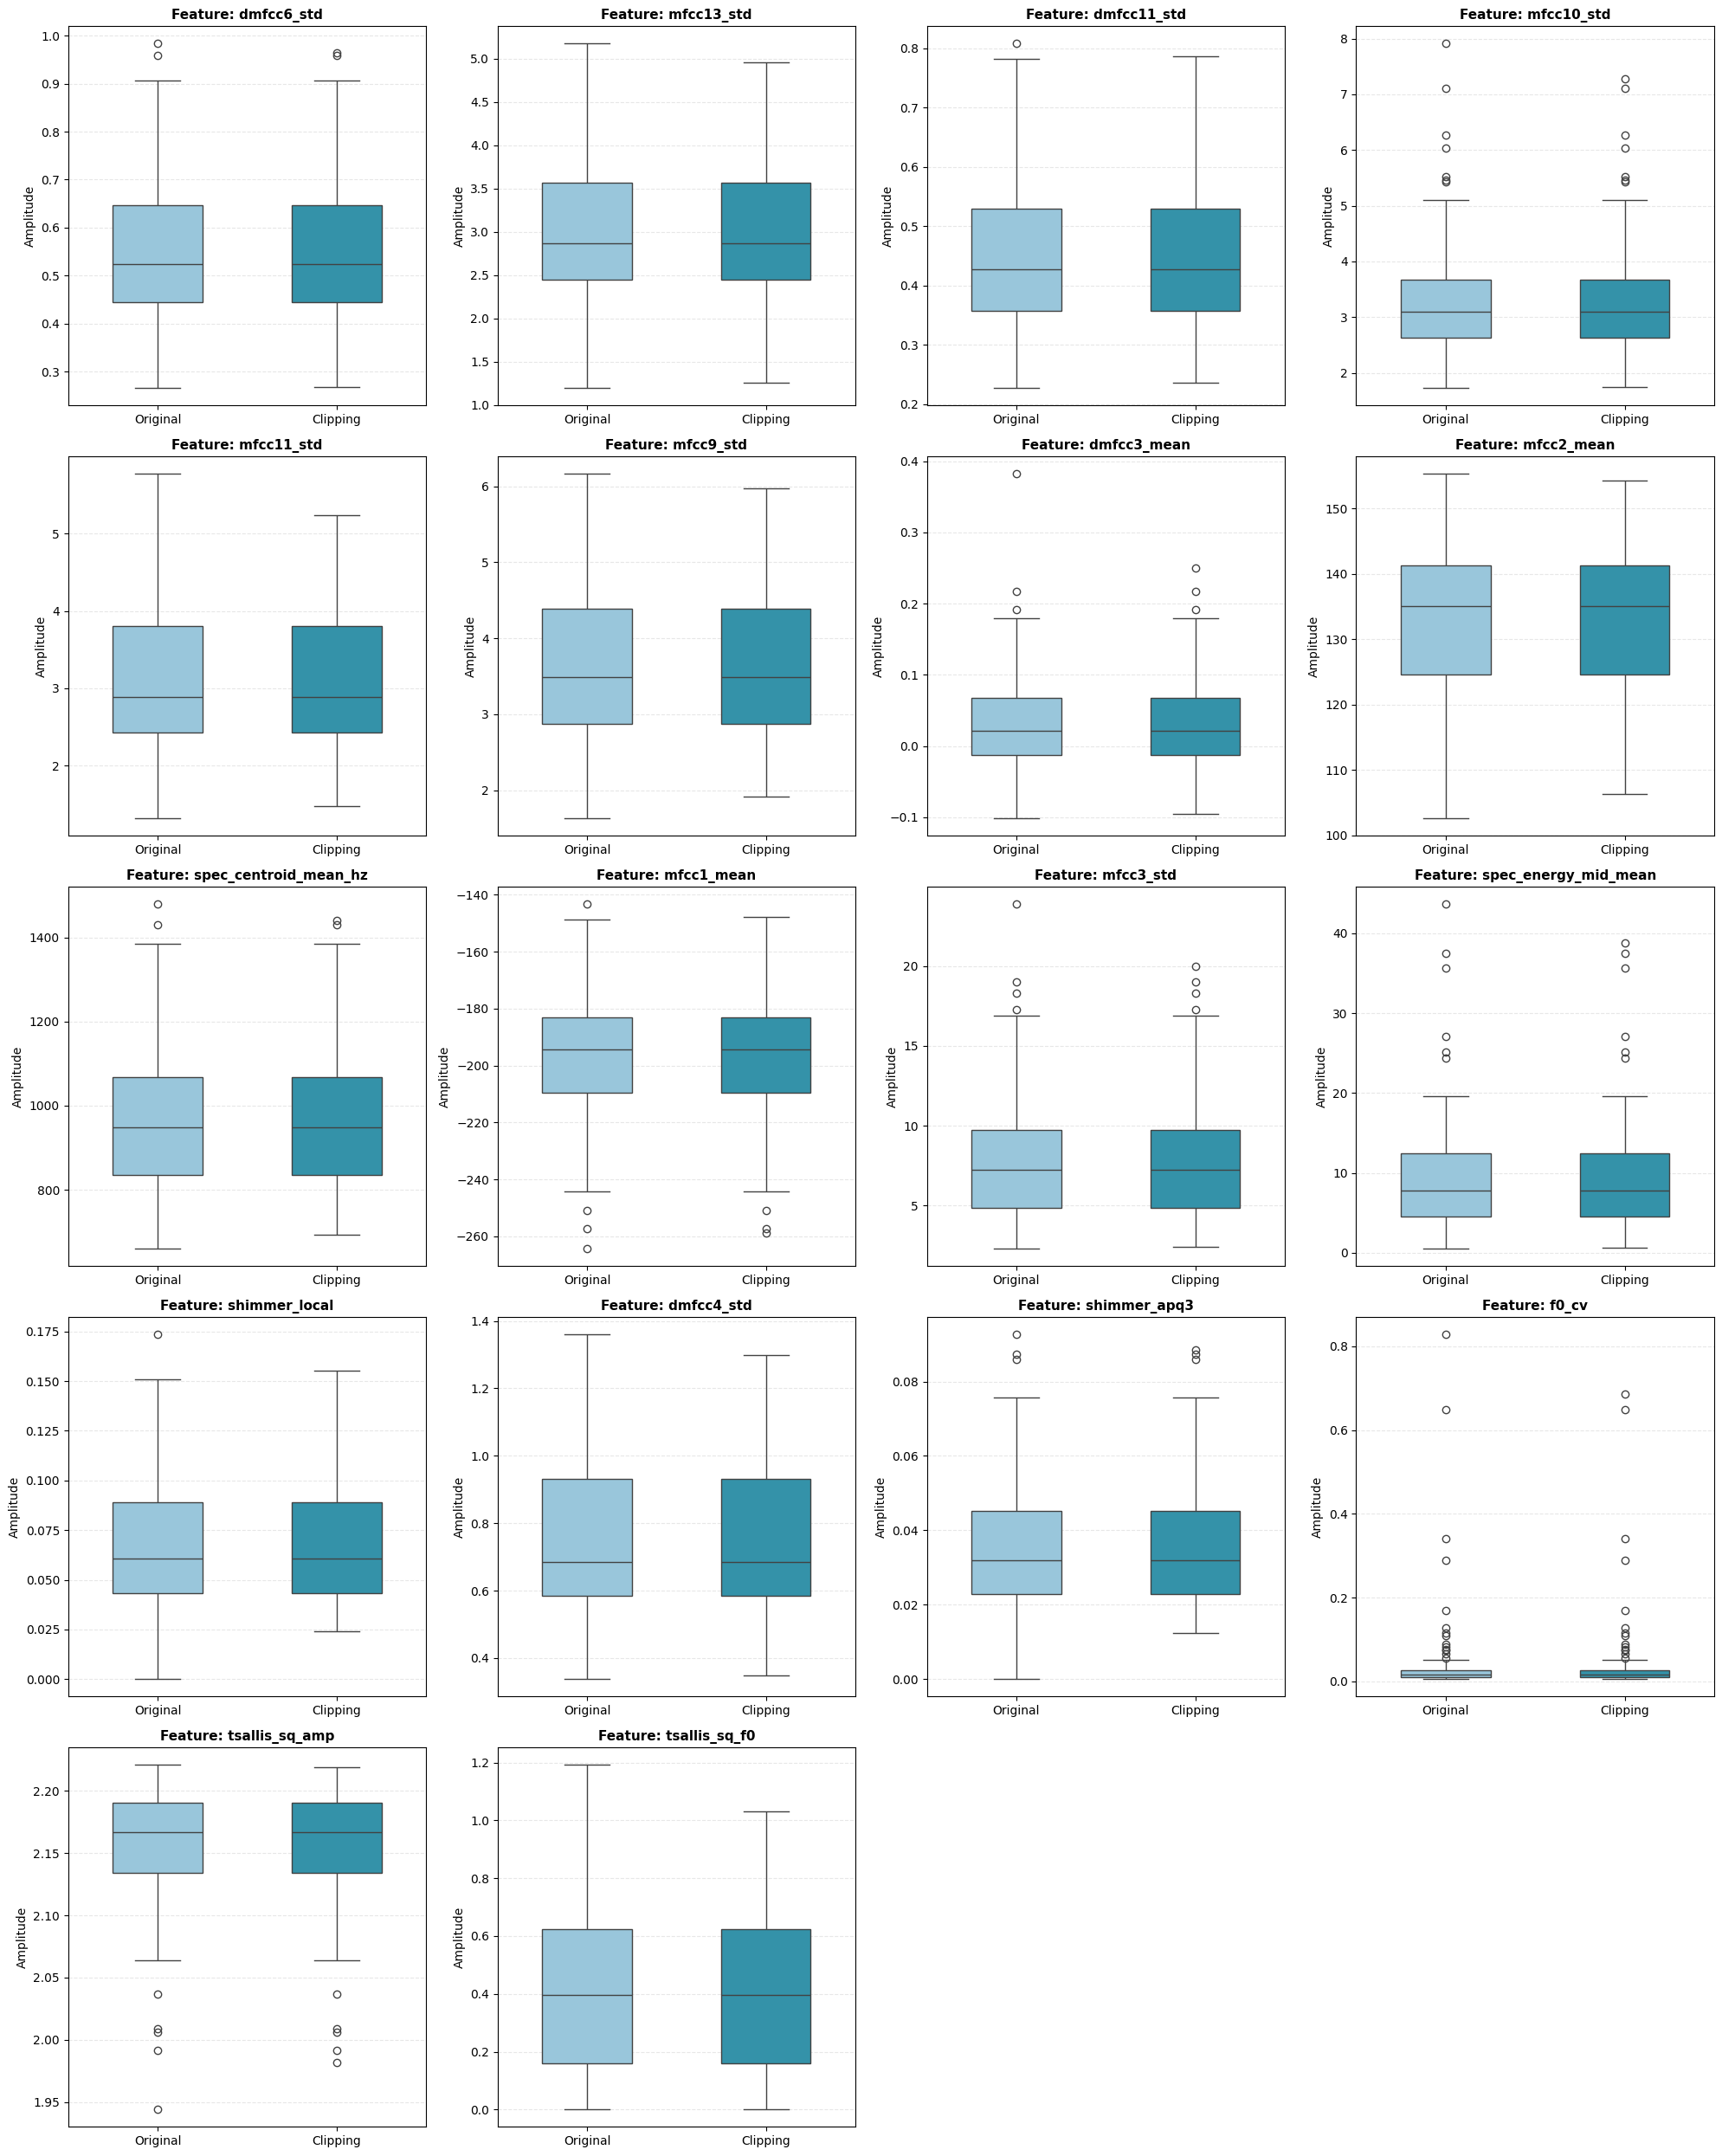

In [18]:
# ============================================
# 18) Bloco: Comparativo de Dados após Quantile Clipping
# ============================================

# Gerar o comparativo entre os dados originais e os dados após o Quantile Clipping
# para uma análise visual rápida de como o clipping afeta a distribuição dos dados.

# 1. Preparar os dados apenas para as Top 16
cols_to_compare = top_features_list_16 + tsallis_cols

# Instanciar e aplicar o clipper apenas nessas colunas para o plot
clipper_viz = QuantileClipper(low=0.01, high=0.99)
clipper_viz.fit(df_imputed[cols_to_compare])
X_clipped_viz = clipper_viz.transform(df_imputed[cols_to_compare])

# Criar DataFrame temporário para o comparativo
df_clipped_viz = pd.DataFrame(X_clipped_viz, columns=cols_to_compare, index=df_imputed.index)

# 2. Identificar quais das Top 16 foram de fato alteradas (possuíam outliers)
affected_features = []
for col in cols_to_compare:
    # Verificação de igualdade considerando precisão de ponto flutuante
    if not np.allclose(df_imputed[col], df_clipped_viz[col], equal_nan=True):
        affected_features.append(col)

num_features = len(affected_features)

if num_features == 0:
    print("Nenhuma das Top 16 features possuiu outliers fora do range (1%-99%).")
else:
    cols_per_row = 4
    num_rows = math.ceil(num_features / cols_per_row)

    print(f"Gerando grade de comparativos para {num_features} features afetadas (dentro do Top 16)...")

    # 3. Configurar a figura
    fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(20, 5 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(affected_features):
        # Preparar dados para o Seaborn (Long Format)
        df_plot = pd.DataFrame({
            'Valor': pd.concat([df_imputed[col], df_clipped_viz[col]]),
            'Tipo': ['Original'] * len(df_imputed) + ['Clipping'] * len(df_clipped_viz)
        })
        
        sns.boxplot(
            data=df_plot, 
            x='Tipo', 
            y='Valor', 
            ax=axes[i], 
            palette={'Original': '#8ecae6', 'Clipping': '#219ebc'},
            width=0.5
        )
        
        axes[i].set_title(f"Feature: {col}", fontsize=11, fontweight='bold')
        axes[i].set_ylabel("Amplitude")
        axes[i].set_xlabel("")
        axes[i].grid(axis='y', linestyle='--', alpha=0.3)

    # Remover eixos excedentes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Top 15 correlações mais altas:
jitter_rap      jitter_local      0.997734
shannon_s1_f0   tsallis_sq_f0     0.992662
f0_cv           f0_std_hz         0.985925
shimmer_apq3    shimmer_local     0.984866
shannon_s1_amp  tsallis_sq_amp    0.981985
jitter_ppq5     jitter_local      0.971789
shimmer_apq11   shimmer_apq5      0.967264
shimmer_apq5    shimmer_local     0.966476
jitter_ppq5     jitter_rap        0.960980
shimmer_apq5    shimmer_apq3      0.945183
shimmer_apq11   shimmer_local     0.930723
dmfcc1_std      mfcc1_std         0.902033
shimmer_apq11   shimmer_apq3      0.883943
dmfcc2_std      mfcc2_std         0.878643
mfcc2_std       dmfcc1_std        0.876678
dtype: float64


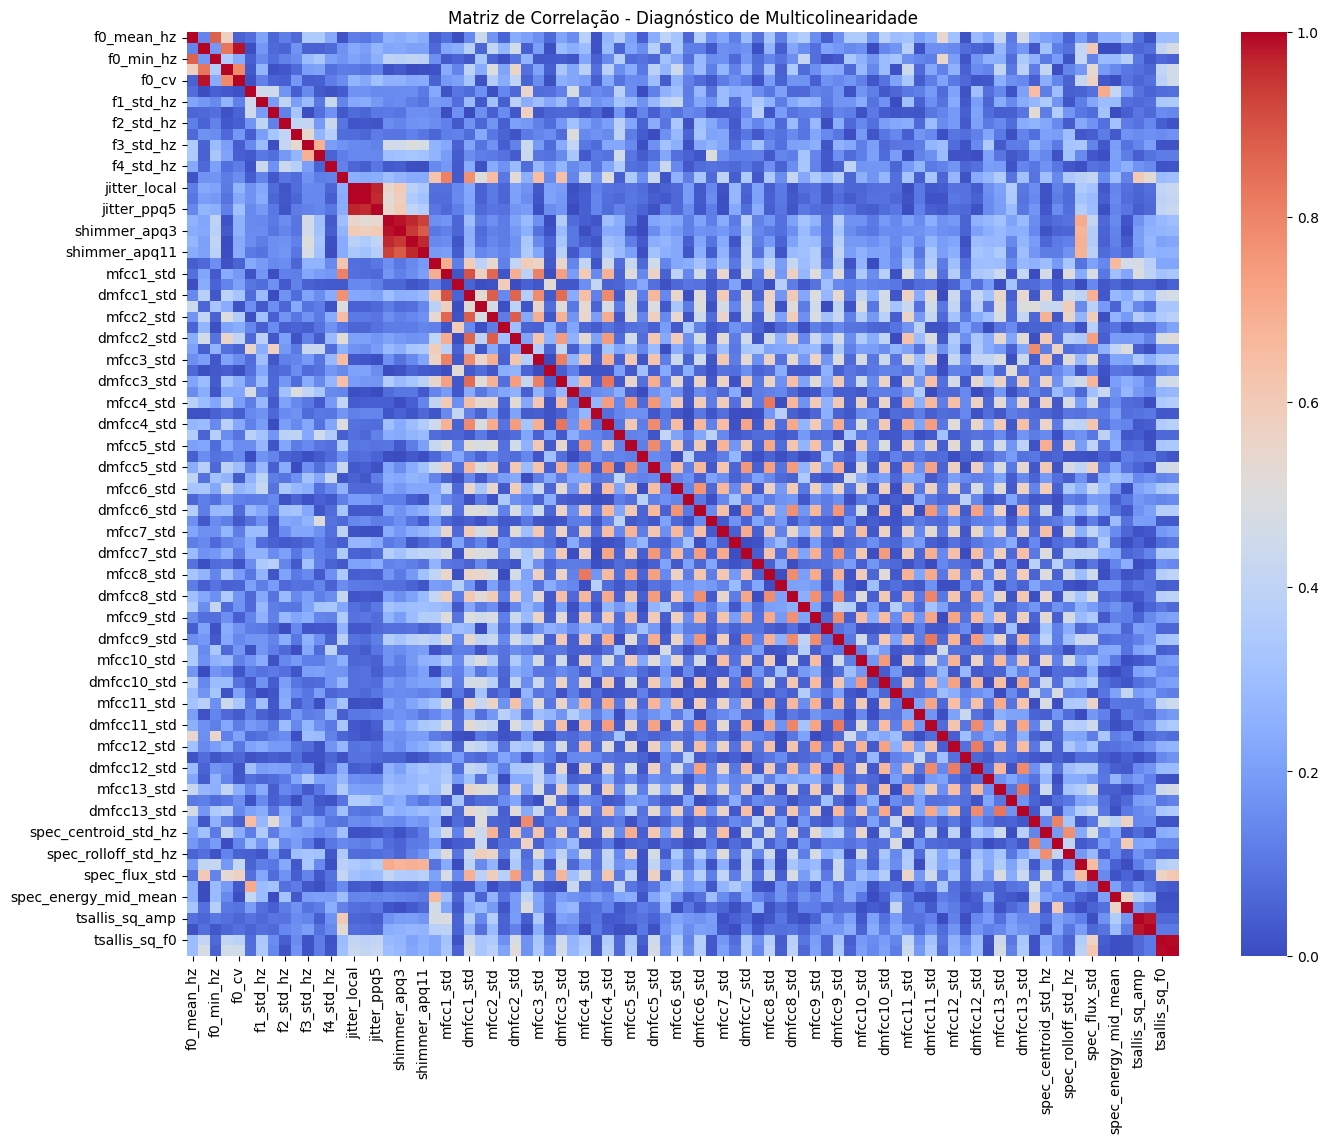


Número de colunas com correlação > 0.9: 9


In [ ]:
# ============================================
# 19) Análise de multicolinearidade
# ============================================

# Carregar o dataset imputado
df = pd.read_csv(DATASET_IMPUTED)

# Remover colunas não numéricas para o cálculo de correlação
cols_to_exclude = ['file_name', 'group', 'status', 'subject_id']
df_numeric = df.drop(columns=[col for col in cols_to_exclude if col in df.columns])

# Calcular a matriz de correlação (Pearson)
corr_matrix = df_numeric.corr().abs()

# Selecionar o triângulo superior da matriz
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar variáveis com correlação superior a CORRELATION_THRESHOLD
highly_correlated = [column for column in upper.columns if any(upper[column] > CORRELATION_THRESHOLD)]

# Preparar dados para visualização (top correlações)
unstacked_corr = upper.unstack().dropna()
sorted_corr = unstacked_corr.sort_values(ascending=False)

# Convertendo a Series para DataFrame para um CSV mais limpo
df_corr_export = sorted_corr.reset_index()
df_corr_export.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Salvar correlações em CSV
df_corr_export.to_csv(CORRELATION_LIST, index=False)

# Mostrar as 15 maiores correlações
print("Top 15 correlações mais altas:")
print(sorted_corr.head(15))

# Plotar um Heatmap das correlações
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Matriz de Correlação - Diagnóstico de Multicolinearidade")
plt.savefig(CORRELATION_GRAPH)
plt.show()

# Contagem de colunas problemáticas
print(f"\nNúmero de colunas com correlação > {CORRELATION_THRESHOLD}: {len(highly_correlated)}")